<a href="https://colab.research.google.com/github/ingorjuela-col/ingorjuela-col/blob/main/Ejercicio_de_Regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

¡Librerías importadas correctamente!

=== 1. INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones de la base de datos: 1000 filas y 6 columnas.
Columnas disponibles en el dataset: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'target']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_0  1000 non-null   float64
 1   feature_1  1000 non-null   float64
 2   feature_2  1000 non-null   float64
 3   feature_3  1000 non-null   float64
 4   feature_4  1000 non-null   float64
 5   target     1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB
None

=== 2. ESTADÍSTICA DESCRIPTIVA BÁSICA ===
         feature_0    feature_1    feature_2    feature_3    feature_4  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.370160     0.142684     0.009733     0.237952    -0.344458   
st

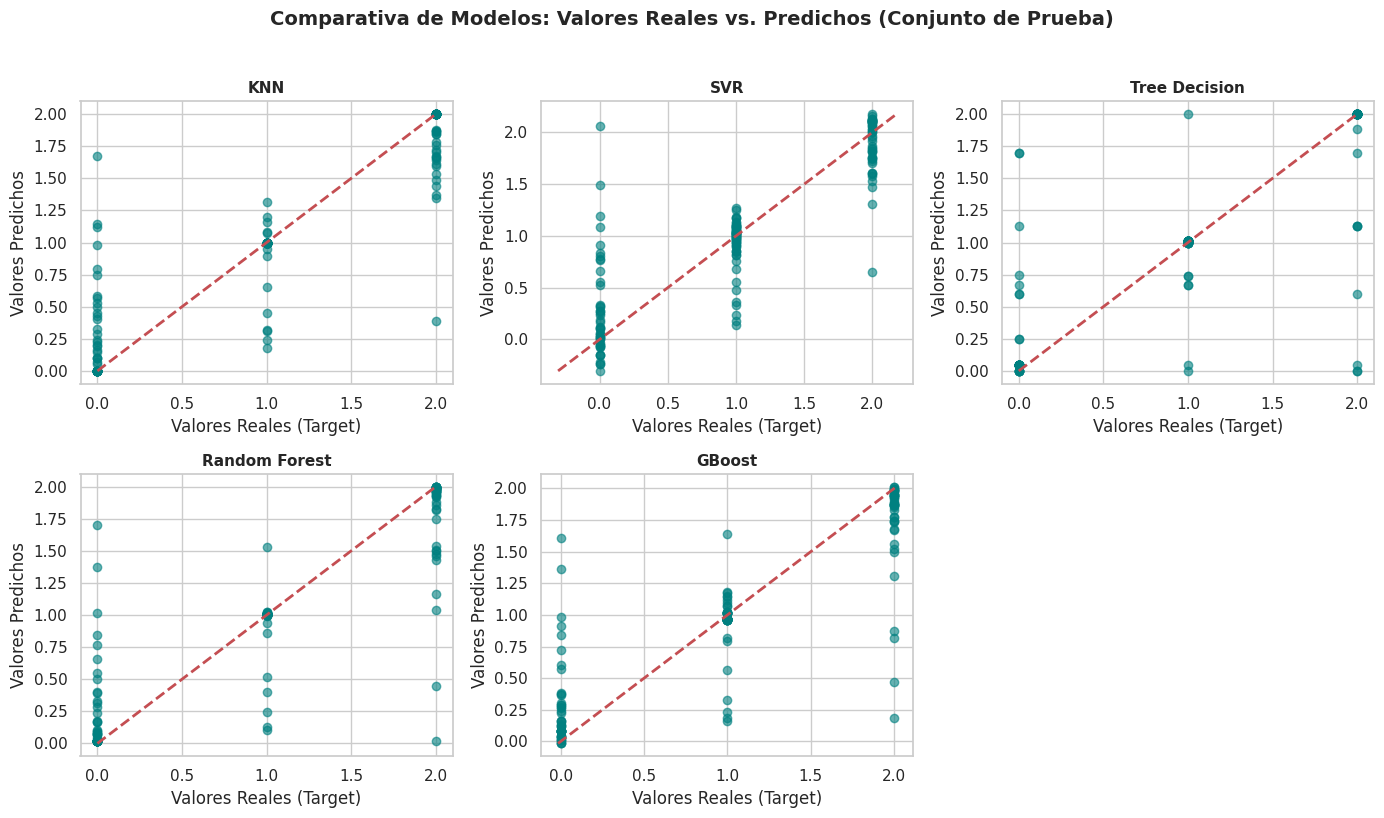

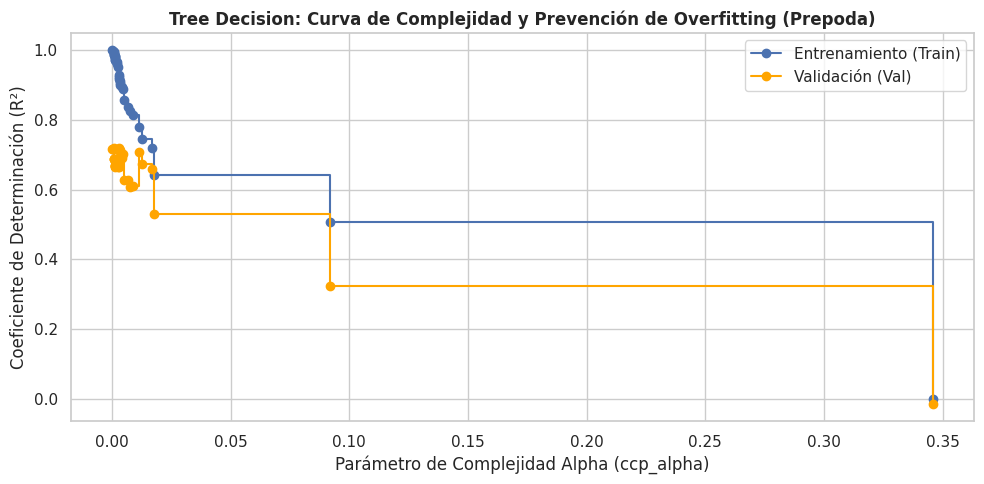


¡Ejecución finalizada con éxito! Ya puedes ver las tablas y gráficos adaptados a tu archivo.


In [2]:
# -*- coding: utf-8 -*-
"""
U2 - Actividad Sumativa: Modelos de Regresión (Corregido para el dataset actual)
Módulo: Métodos Supervisados
"""

# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS NECESARIAS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set_theme(style="whitegrid")
print("¡Librerías importadas correctamente!\n")


# ==============================================================================
# 1. CARGA Y EXPLORACIÓN INICIAL DE LA BASE DE DATOS (EDA)
# ==============================================================================
df = pd.read_csv('dataset.csv')

print("=== 1. INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones de la base de datos: {df.shape[0]} filas y {df.shape[1]} columnas.")
print(f"Columnas disponibles en el dataset: {list(df.columns)}\n")
print(df.info())

print("\n=== 2. ESTADÍSTICA DESCRIPTIVA BÁSICA ===")
print(df.describe())

print("\n=== 3. VERIFICACIÓN DE VALORES FALTANTES (NULOS) ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "No se encontraron valores nulos en el dataset.")

# DEFINICIÓN DE LA VARIABLE OBJETIVO (Target)
# Ajustamos a la columna real que contiene tu dataset ('target')
VARIABLE_TARGET = 'target'

if VARIABLE_TARGET not in df.columns:
    raise ValueError(f"La columna objetivo '{VARIABLE_TARGET}' no existe en el dataset. Revisa el nombre exacto.")

# Separamos las características (X) de la variable objetivo (y)
X = df.drop(columns=[VARIABLE_TARGET])
y = df[VARIABLE_TARGET]

# Identificamos automáticamente qué columnas son numéricas y cuáles son categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"\nVariables Numéricas detectadas ({len(num_cols)}): {num_cols}")
print(f"Variables Categóricas detectadas ({len(cat_cols)}): {cat_cols}")


# ==============================================================================
# 2. DIVISIÓN DEL DATASET (70% Train / 15% Val / 15% Test)
# ==============================================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"\n=== 4. PARTICIÓN DE DATOS ===")
print(f"Entrenamiento (Train): {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validación (Val):      {X_val.shape[0]} registros ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Prueba (Test):         {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)")


# ==============================================================================
# 3. PREPROCESADOR (ColumnTransformer)
# ==============================================================================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ] if cat_cols else [('num', StandardScaler(), num_cols)]
)


# ==============================================================================
# 4. CONFIGURACIÓN DE MODELOS Y BÚSQUEDA DE HIPERPARÁMETROS (GridSearch CV=5)
# ==============================================================================
models_config = {
    'KNN': (KNeighborsRegressor(), {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan']
    }),
    'SVR': (SVR(), {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    }),
    'Tree Decision': (DecisionTreeRegressor(random_state=42), {
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }),
    'Random Forest': (RandomForestRegressor(random_state=42), {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 5]
    }),
    'GBoost': (GradientBoostingRegressor(random_state=42), {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5]
    })
}

best_models = {}

print("\n=== 5. INICIANDO OPTIMIZACIÓN CON GRIDSEARCH (CV=5) ===")
for name, (model, params) in models_config.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=params,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"  -> [{name}] Mejor MSE obtenido en validación cruzada: {-grid.best_score_:.4f}")


# ==============================================================================
# 5. EVALUACIÓN Y GENERACIÓN DE TABLAS COMPARATIVAS (TRAIN, VAL, TEST)
# ==============================================================================
def evaluar_modelo(modelo, X_data, y_true):
    y_pred = modelo.predict(X_data)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(np.unique(y_true)) > 1 else 0.0
    return mse, mae, r2, corr, y_pred

results_train, results_val, results_test = [], [], []
predictions_test = {}

for name, model in best_models.items():
    mse_tr, mae_tr, r2_tr, corr_tr, _ = evaluar_modelo(model, X_train, y_train)
    results_train.append([name, mse_tr, mae_tr, r2_tr, corr_tr])

    mse_v, mae_v, r2_v, corr_v, _ = evaluar_modelo(model, X_val, y_val)
    results_val.append([name, mse_v, mae_v, r2_v, corr_v])

    mse_t, mae_t, r2_t, corr_t, y_pred_t = evaluar_modelo(model, X_test, y_test)
    results_test.append([name, mse_t, mae_t, r2_t, corr_t])
    predictions_test[name] = y_pred_t

cols = ['Método', 'MSE', 'MAE', 'R²', 'Correlación']
df_results_train = pd.DataFrame(results_train, columns=cols)
df_results_val = pd.DataFrame(results_val, columns=cols)
df_results_test = pd.DataFrame(results_test, columns=cols)

print("\n" + "="*50)
print(" TABLA COMPARATIVA 1: CONJUNTO DE ENTRENAMIENTO (TRAIN)")
print("="*50)
print(df_results_train.to_string(index=False))

print("\n" + "="*50)
print(" TABLA COMPARATIVA 2: CONJUNTO DE VALIDACIÓN (VAL)")
print("="*50)
print(df_results_val.to_string(index=False))

print("\n" + "="*50)
print(" TABLA COMPARATIVA 3: CONJUNTO DE PRUEBA (TEST)")
print("="*50)
print(df_results_test.to_string(index=False))


# ==============================================================================
# 6. GRÁFICA COMPARATIVA: VALORES REALES VS. PREDICHOS (PRUEBA)
# ==============================================================================
plt.figure(figsize=(14, 8))
for i, (name, y_pred) in enumerate(predictions_test.items(), 1):
    plt.subplot(2, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.6, color='teal')

    min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    if min_val == max_val:
        min_val -= 1
        max_val += 1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.title(f'{name}', fontsize=11, fontweight='bold')
    plt.xlabel('Valores Reales (Target)')
    plt.ylabel('Valores Predichos')

plt.suptitle('Comparativa de Modelos: Valores Reales vs. Predichos (Conjunto de Prueba)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ==============================================================================
# 7. ÁRBOL DE DECISIÓN: PREPODA Y CURVA DE COMPLEJIDAD (CCP ALPHA)
# ==============================================================================
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)

dt_base = DecisionTreeRegressor(random_state=42)
path = dt_base.cost_complexity_pruning_path(X_train_prep, y_train)
ccp_alphas = path.ccp_alphas

train_scores, val_scores = [], []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_prep, y_train)
    train_scores.append(r2_score(y_train, clf.predict(X_train_prep)))
    val_scores.append(r2_score(y_val, clf.predict(X_val_prep)))

plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label="Entrenamiento (Train)", drawstyle="steps-post", color='b')
plt.plot(ccp_alphas, val_scores, marker='o', label="Validación (Val)", drawstyle="steps-post", color='orange')
plt.xlabel("Parámetro de Complejidad Alpha (ccp_alpha)")
plt.ylabel("Coeficiente de Determinación (R²)")
plt.title("Tree Decision: Curva de Complejidad y Prevención de Overfitting (Prepoda)", fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n¡Ejecución finalizada con éxito! Ya puedes ver las tablas y gráficos adaptados a tu archivo.")